In [16]:
import numpy as np
import pandas as pd
from sklearn import set_config
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [17]:
# Output dataframes instead of arrays
set_config(transform_output="pandas")

penguins = pd.read_csv("/Users/doren/DSI/module4-LCR/LCR/01_materials/notebooks/dataset/penguins.csv")
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   flipper_length_mm  342 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 5.5 KB


In [18]:
penguins.agg(['min', 'max'])

,bill_length_mm,flipper_length_mm
min,32.1,172
max,59.6,231


In [19]:
penguins_copy = penguins.copy()

In [20]:
# scale our variables

scaler = StandardScaler()

standardized_penguins = scaler.fit_transform(penguins_copy)
standardized_penguins

,bill_length_mm,flipper_length_mm
0,-0.884499,-1.418347
1,-0.811126,-1.062250
2,-0.664380,-0.421277
3,-1.324737,-0.563715
4,-0.847812,-0.777373
...,...,...
337,2.178824,0.433355
338,-0.077396,0.077258
339,1.041543,-0.563715
340,1.261662,0.647013


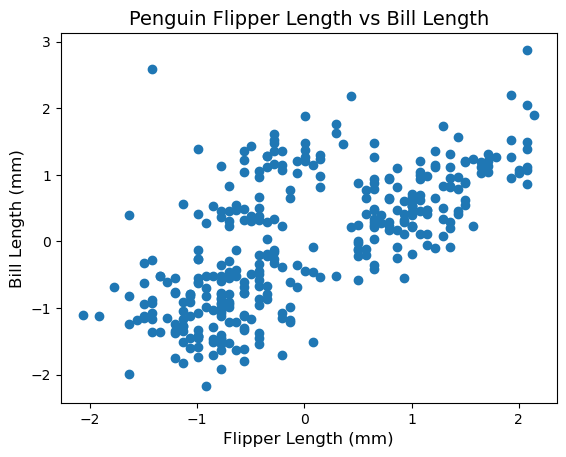

In [21]:
# Scatter plot for bill_length_mm vs flipper_length_mm
plt.scatter(standardized_penguins['flipper_length_mm'], standardized_penguins['bill_length_mm'])

# Adding labels and title
plt.title('Penguin Flipper Length vs Bill Length', fontsize=14)
plt.ylabel('Bill Length (mm)', fontsize=12)
plt.xlabel('Flipper Length (mm)', fontsize=12)

# Display the plot
plt.show()

In [22]:
# perform K-Means clustering
kmeans = KMeans(n_clusters= 5, random_state=123, n_init=10)

In [23]:
clusters = kmeans.fit(standardized_penguins)

In [24]:
clusters.labels_

array([1, 1, 4, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1,
       1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 1, 1, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1,
       1, 1, 4, 1, 1, 1, 2, 1, 4, 1, 4, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1,
       1, 1, 4, 1, 4, 1, 1, 4, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 2, 3, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2,
       3, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 3, 3, 0, 3, 3, 3, 2, 3, 2, 2, 2, 3, 2, 2, 3, 3, 2,
       3, 2, 3, 2, 3, 2, 2, 3, 2, 3, 4, 0, 0, 4, 0, 4, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 0, 0, 4, 0, 4, 0, 4, 0, 4, 0, 0,

In [25]:
standardized_penguins_with_clusters = standardized_penguins.copy()

In [26]:
standardized_penguins_with_clusters["Cluster"] = clusters.labels_

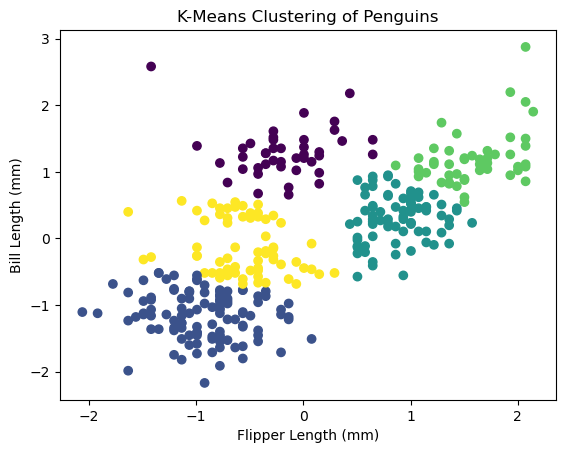

In [27]:
# Plot the clusters
plt.scatter(standardized_penguins_with_clusters['flipper_length_mm'], standardized_penguins_with_clusters['bill_length_mm'], c=standardized_penguins_with_clusters['Cluster'])
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.title('K-Means Clustering of Penguins')
plt.show()

In [28]:
# elbow method to find the optimal number of clusters
# SKlearn already does this

clusters.inertia_


91.47610853298522

In [29]:
#find optimal value of K
penguin_clust_ks = pd.DataFrame(columns = ["k","wssd"])
penguin_clust_ks

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state=123)
    kmeans.fit(standardized_penguins)
    current_k = pd.DataFrame({"k":[k], "wssd":[kmeans.inertia_]})
    penguin_clust_ks = pd.concat([penguin_clust_ks, current_k], ignore_index=True)

/var/folders/51/mcycgk1j10v6n47l_1w_g1080000gn/T/ipykernel_70573/2949982188.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  penguin_clust_ks = pd.concat([penguin_clust_ks, current_k], ignore_index=True)


In [30]:
penguin_clust_ks

,k,wssd
0,1,684.000000
1,2,247.016625
2,3,157.815322
3,4,128.451298
4,5,94.061233
5,6,79.419564
6,7,69.965331
7,8,60.616734
8,9,55.030936
9,10,52.111475


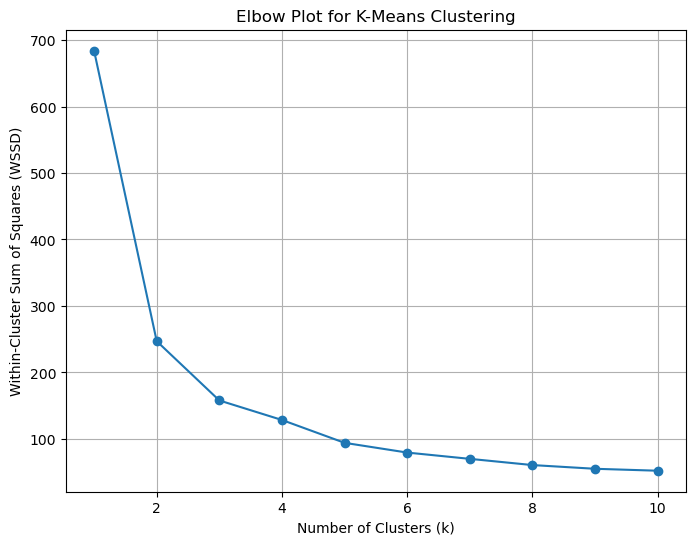

In [31]:
# Create the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(penguin_clust_ks['k'], penguin_clust_ks['wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
#plt.xticks(penguin_clust_ks['k'])  # Optional: to ensure all k values are shown on the x-axis
plt.grid(True)
plt.show()